# Porównanie klasyfikatorów
- Regresja logistyczna Logistic Regression -- cechy oryginalne oraz rozszerzone,
- Liniowa analiza dyskryminacyjna (LDA) – cechy oryginalne oraz rozszerzone,
- Kwadratowa analiza dyskryminacyjna (QDA) – oryginalne cechy,
- Bayesowski klasyfikator oparty na nieparametrycznej estymacji gęstości (Kernel Density Estimation).

In [21]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt


In [36]:
trainset  = pd.read_csv(".data/train.csv", header=0)
x_test = pd.read_csv(".data/test.csv", header=0)
x_train = trainset.drop('y', axis=1)
y_train = trainset['y']
trainset

,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,x_11,y
0,-3.518033,-0.503242,-1.776150,1.777898,-2.930268,4.531097,-3.052045,0.669047,0.629556,3.209360,-0.972837,0
1,-3.063784,1.182584,-0.060169,4.434872,-2.389759,0.689593,1.792627,-3.466945,-0.909568,-1.154546,2.729984,0
2,1.598471,-0.324232,-0.756554,0.637456,1.244039,2.473573,-0.904594,-1.143389,0.493386,4.050946,-1.506629,1
3,1.421484,-0.831693,1.625747,0.422182,2.072835,0.300084,1.171992,-0.101498,-1.700709,-1.419759,-0.205818,1
4,-0.590877,-1.597617,1.928054,3.157458,-2.089301,2.330981,0.657916,-2.094596,0.121473,-1.790393,1.101502,0
...,...,...,...,...,...,...,...,...,...,...,...,...
145,0.994457,3.944333,2.762752,-3.004972,3.937074,-2.158928,3.402317,1.375853,3.048543,-1.167554,3.093095,1
146,-4.393115,-1.716634,2.632869,-3.579165,-0.036920,-2.040971,2.972168,1.359803,-2.252148,-5.035654,2.681503,1
147,-4.338007,1.297565,2.714429,-0.145689,0.024905,-0.030147,2.201208,-3.312286,0.797241,5.296627,1.651804,0
148,-3.149787,-1.776074,-1.240185,-0.330952,0.798020,-1.584474,1.469859,-3.123256,-1.037559,-4.095776,0.037098,1


Sprawdźmy rozkłady poszczególnych zmiennych

array([[<Axes: title={'center': 'x_1'}>, <Axes: title={'center': 'x_2'}>,
        <Axes: title={'center': 'x_3'}>],
       [<Axes: title={'center': 'x_4'}>, <Axes: title={'center': 'x_5'}>,
        <Axes: title={'center': 'x_6'}>],
       [<Axes: title={'center': 'x_7'}>, <Axes: title={'center': 'x_8'}>,
        <Axes: title={'center': 'x_9'}>],
       [<Axes: title={'center': 'x_10'}>,
        <Axes: title={'center': 'x_11'}>, <Axes: >]], dtype=object)

<Figure size 1000x600 with 0 Axes>

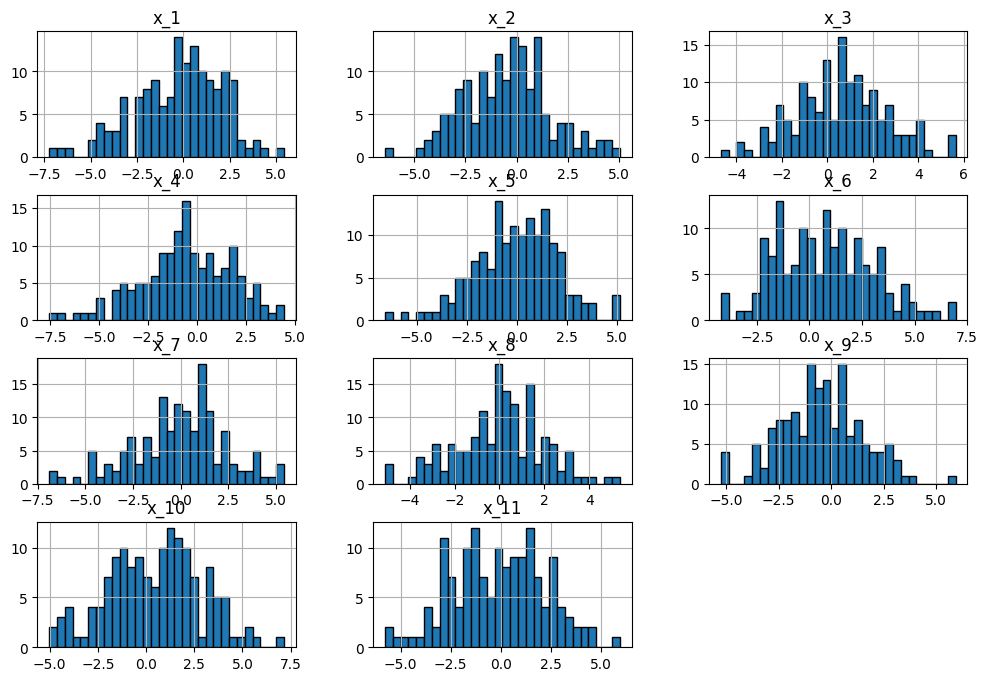

In [30]:
plt.figure(figsize=(10, 6))
x_train.hist(bins=30, edgecolor='black', figsize=(12, 8))

In [71]:
np.count_nonzero(y_train) / len(y_train)

np.float64(0.5266666666666666)

In [111]:
columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-score']
results = []

# Repeated Stratified K-fold K
Do kroswalidacji uzyjemy powtórzonego  K-folda ze wzlędu na niewielki rozmiar zbioru treningowego


In [112]:
from sklearn.model_selection import RepeatedStratifiedKFold
def Skfold(model, n_splits=5, n_repeats=6):
    rskf = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=42)
    scores = []
    for train_index, test_index in rskf.split(x_train, y_train):
        x_train_fold, x_test_fold = x_train.iloc[train_index], x_train.iloc[test_index]
        y_train_fold, y_test_fold = y_train.iloc[train_index], y_train.iloc[test_index]
        model.fit(x_train_fold, y_train_fold)
        score = model.score(x_test_fold, y_test_fold)
        scores.append(score)
    return np.mean(scores), np.std(scores)


# Regresja Liniowa na oryginalnych danych 

In [113]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

LR = LogisticRegression()
LR.fit(x_train, y_train)
y_pred_LR = LR.predict(x_train)  
LR.score(x_train, y_train)

results.append(['Logistic Regression',Skfold(LR)])

# Rozszerzona regresja logistyczna
do zbioru zmiennych wyjaśniających zostały dodane kwadraty zmiennych

In [114]:
x_train_squared = x_train.copy()

for i in range(1,12):
    x_train_squared[f'x_{i}^2'] = x_train_squared[f'x_{i}']**2
    for j in range(i+1, 12):
        x_train_squared[f'x_{i}*x_{j}'] = x_train_squared[f'x_{i}'] * x_train_squared[f'x_{j}']
        
LRE = LogisticRegression()
LRE.fit(x_train_squared, y_train)

results.append(['Logistic Regression with Squared Features', Skfold(LRE)])



# LDA 

In [115]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
LDA = LinearDiscriminantAnalysis()
LDA.fit(x_train, y_train)

results.append(['LDA', Skfold(LDA)])

# Rozszerzone LDA 

In [116]:
LDA_squared = LinearDiscriminantAnalysis()
LDA_squared.fit(x_train_squared, y_train)

results.append(['LDA with Squared Features', Skfold(LDA_squared)])


# QDA


In [117]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
QDA = QuadraticDiscriminantAnalysis()
QDA.fit(x_train, y_train)   
results.append(['QDA', Skfold(QDA)])


In [118]:
results

[['Logistic Regression',
  (np.float64(0.7866666666666668), np.float64(0.07383665655927181))],
 ['Logistic Regression with Squared Features',
  (np.float64(0.7866666666666668), np.float64(0.07383665655927181))],
 ['LDA', (np.float64(0.7755555555555557), np.float64(0.07248669524577821))],
 ['LDA with Squared Features',
  (np.float64(0.7755555555555557), np.float64(0.07248669524577821))],
 ['QDA', (np.float64(0.8744444444444445), np.float64(0.06536696035592324))]]